**Proyecto Final Electronica (Nacho Ibáñez y Marcos Aldana)** 
---
---
In this project, we explore the concept of finite potential wells, which is fundamental
to understanding quantum effects in semiconductors.

In [7]:
#Librerias---------------------
import numpy as np
import math as mt
import matplotlib.pyplot as plt
import random
from sympy import symbols, sympify, diff
import scipy as sp

**Idea NEWTON RAPHSON** 
---
---

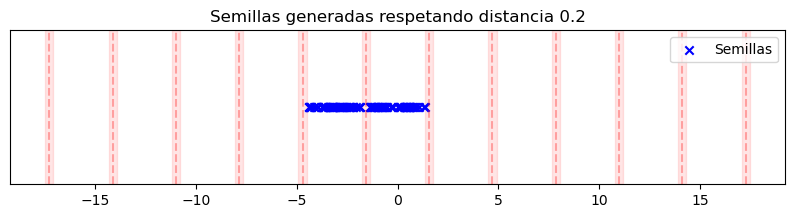

In [8]:
def generar_semillas_seguras(n_semillas, delta=0.1, rango_n=(-1, 1)):
    """
    n_semillas: Cantidad de semillas a generar
    delta: Distancia mínima a la asíntota (zona de seguridad)
    rango_n: Tupla (min, max) de los periodos (n*pi) donde buscar
    """
    
    # Elegir aleatoriamente en qué periodo 'n' cae cada semilla
    # Si rango_n es (-5, 5), elegirá enteros entre -5 y 5
    n_elegidos = np.random.randint(rango_n[0], rango_n[1], n_semillas)
    
    # Generar un desplazamiento aleatorio dentro de la zona segura
    # La zona segura va de (-pi/2 + delta) a (pi/2 - delta) respecto al centro n*pi
    limite_seguro = (np.pi / 2) - delta
    desplazamientos = np.random.uniform(-limite_seguro, limite_seguro, n_semillas)
    
    # Calcular la posición final: Centro del periodo + desplazamiento
    semillas = (n_elegidos * np.pi) + desplazamientos
    
    return semillas




delta_seguridad = 0.2  # Distancia a la asíntota
semillas = generar_semillas_seguras(100, delta=delta_seguridad)

# Visualización para comprobar
plt.figure(figsize=(10, 2))
# Dibujar asíntotas en rojo
for n in range(-6, 6):
    asintota = np.pi/2 + n*np.pi
    plt.axvline(asintota, color='red', linestyle='--', alpha=0.3)
    # Dibujar la zona prohibida
    plt.axvspan(asintota - delta_seguridad, asintota + delta_seguridad, color='red', alpha=0.1)

plt.scatter(semillas, np.zeros_like(semillas), marker='x', color='blue', label='Semillas')
plt.title(f"Semillas generadas respetando distancia {delta_seguridad}")
plt.yticks([])
plt.legend()
plt.show()

**Código principal**
---
---

Even roots: [1.4275517800931634, 4.271095337633531, 7.068891237347651, 9.678884018488278].
Odd roots: [2.852341894455552, 5.679207796333668, 8.423203932389944].


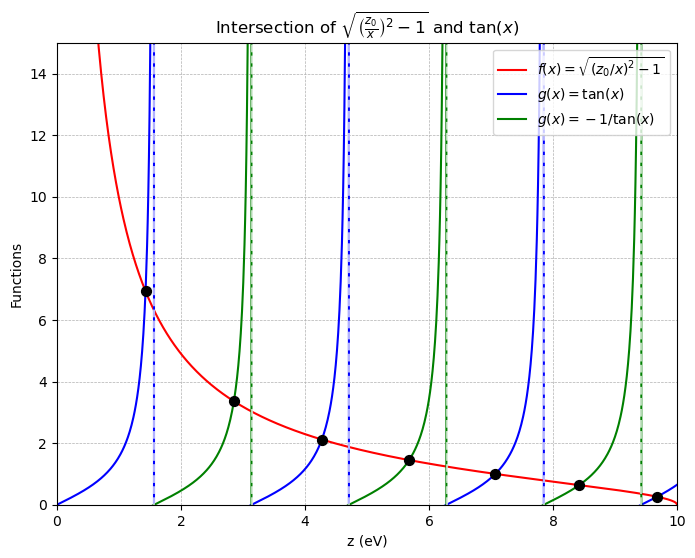

In [ ]:
#WE DEFINE THE MATHEMATICAL FUNCTIONS ---------------------


#SQUARE ROOT FUNCTION 
def sq(x, z0):
    with np.errstate(all='ignore'): # used to manage floating-point error handling (e.g., divide-by-zero, overflow) 
        val = np.sqrt((z0 / x)**2 - 1) if x > 0 else np.nan #We make an if-else in case our sqrt is imaginary
    return val

# TANGENT FUNCTION
def tan_func(x):
    return np.tan(x)

#COTANGENT FUNCTION (-1/tan).
def ctg_func(x):
    return -1 / np.tan(x)

"""
WE MAKE THE DIFFERENCE BETWEEN FUNCTIONS F(X) AND G (X) BECAUSE NEWTON RAPHSON SEARCHES FOR 0 IN A FUNCTION

F(X) = G(X) --> F(X)-G(X) = 0

H(X) = F(X)-G(X)
"""


#DIFFERENCE FOR ODD SOLUTIONS (SQRT - CTNG)
def diff_im(x, z0):
    return sq(x, z0) - ctg_func(x)


#DIFFERENCE FOR EVEN SOLUTIONS (SQRT - CTNG)
def diff_par(x, z0):
    return sq(x, z0) - tan_func(x)

#Método Newton-Raphson -----------

#NEWTON RAPHSON ODD FUNCTION
def newton_im(sq, ctg_func, x0, eps, z0, max_iter=10000, step=0.005): #sq and crg_func will be fed later when we call the fucntion
    xold = x0
    for j in range(max_iter):
        func = diff_im(xold, z0) #We feed our odd func it's initial variables
        dfunc = (diff_im(xold + step, z0) - diff_im(xold - step, z0)) / (2 * step) #f′(x)≈f(x+h)−f(x−h)/2h --> finite differnce definition
        if dfunc == 0: break   # f'(x) = 0 --> GET OUT
        xnew = xold - func / dfunc  #Newton raphson core

        if abs(xnew - xold) < eps:
            return xnew
        xold = xnew
    return None


#Analogous
def newton_par(sq, tan_func, x0, eps, z0, max_iter=10000, step=0.005):
    xold = x0
    for j in range(max_iter):
        func = diff_par(xold, z0)
        dfunc = (diff_par(xold + step, z0) - diff_par(xold - step, z0)) / (2 * step)
        if dfunc == 0: break
        xnew = xold - func / dfunc
        if abs(xnew - xold) < eps:
            return xnew
        xold = xnew
    return None




#Functions to calculuate the intersection points (MAKING THE SAFE MARGINGS TO GENERATE X0)----------
def roots_par(z0, eps):
    par_def = [] #List to store the safe values
    #We search for intervals like [n*pi, n*pi + pi/2]
    num_intervalos = int(z0 / np.pi) + 1 #How many cycles of the tangent function fit before hitting our wall z0
                                         #We add the +1 just in case there are more solutions 
    
    for i in range(num_intervalos):
        a = i * np.pi #Begining of our available region for seeds
        b = min(i * np.pi + np.pi / 2, z0 - 1e-9)   #Limit that defines the barrier so it doesn't pass beyond z0 or the asymtote
        
        """
        BASICALLY THE MIN FUNCTION WILL CHOOSE BETWEEN VALUE min(c,d) THE MINIMUM ONE SO 
        WE DON'T PASS OUR STABLISHED LIMIT OF z0 (and waste computational power)
        """
        if a > z0: break #In case the beginning of our region already overcame z0
        
        #Systematic sampling: we take samples from the middle of the interval
        seeds = np.linspace(a + 0.01, b - 0.01, 5) #Interval were our seeds will live
        for x0 in seeds:
            root = newton_par(sq, tan_func, x0, eps, z0)
            if root is not None and 0 < root < z0:  #Verify if it converged
                if not any(abs(root - r) < 1e-4 for r in par_def): #Verify if the next root is the same as the previous
                                                                   # By comparing the new root "root" to "r" roots in our list par_def
                    par_def.append(root)
    return sorted(par_def) #Roots found from higher to lower




#Analogous
def roots_im(z0, eps):   
    im_def = []
    num_intervalos = int(z0 / np.pi) + 1
    
    for i in range(num_intervalos):
        a = i * np.pi + np.pi / 2
        b = min(i * np.pi + np.pi, z0 - 1e-9)
        
        if a > z0: break
        
        seeds = np.linspace(a + 0.01, b - 0.01, 5)
        for x0 in seeds:
            root = newton_im(sq, ctg_func, x0, eps, z0)
            if root is not None and 0 < root < z0:
                if not any(abs(root - r) < 1e-4 for r in im_def):
                    im_def.append(root)
    return sorted(im_def)




#Graphics [AI HELP]--------------------

def plot_functions(z0, x_par, x_im):
    x_values = np.linspace(0.001, 10, 1000)
    y_sq = [sq(x, z0) for x in x_values]
    y_ctg = [ctg_func(x) for x in x_values]
    y_tan = [tan_func(x) for x in x_values]

    plt.figure(figsize=(8, 6))
    plt.plot(x_values, y_sq, 'r', label=r'$f(x) = \sqrt{(z_0/x)^2 - 1}$')
    plt.plot(x_values, y_tan, 'b', label=r'$g(x) = \tan(x)$')
    plt.plot(x_values, y_ctg, 'g', label=r'$g(x) = -1/\tan(x)$')

    #Plotting singularities (asymptotes)
    sing = np.arange(np.pi/2, 10, np.pi/2)
    for s in sing:
        plt.axvline(s, color="white", linestyle="--", alpha=0.7)

    # Plot even intersection points
    for x in x_par:
        
        plt.scatter(x, sq(x, z0), color='black', s=50, zorder=5)
    
    # Plot odd intersection points
    for x in x_im:

        plt.scatter(x, sq(x, z0), color='black', s=50, zorder=5)

    plt.ylim(0, 15)
    plt.xlim(0, 10)
    plt.xlabel("z (eV)")
    plt.ylabel("Functions")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.title(r"Intersection of $\sqrt{\left(\frac{z_0}{x}\right)^2 - 1}$ and $\tan(x)$")
    plt.show()

#--------------------------------------------------------------
#---------Principal compiling (constant defintions)------------
#-------------------------------------------------------------

if __name__ == "__main__":
    
    
    z0 = 10   #We define z0 arbitrarly

    eps = 1e-5 #Tolerance for netwon raphson (basically how precisley do we want to be close to 0)

    # We asign to each root function a variable so we can later print the roots.
    x_par = roots_par(z0, eps) 
    x_im = roots_im(z0, eps)

    print(f"Even roots: {x_par}.")
    print(f"Odd roots: {x_im}.")

    plot_functions(z0, x_par, x_im)


**Apartado 2**
---
---
To calculate the effective mass, we will use the formula provided on *“la-mecanica-cuantica.blogspot”*, as follows:

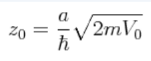

After solving for the effective mass, we obtain the following effective mass for our fixed z₀ = 10.

In [47]:
#Variables----------------------
z0 = 10
a = 3 * 10**(-10)   #metros
V = 3 * 1.602 * 10**(-19)   #Julios
Hbar = 1.0545718 * 10**(-34)

m_effe = ((z0 * Hbar) / a)**2 / (2 * V)  #Formula despejada 


print(f"The effective mass for a z0 = {z0}, is: {m_effe} kg.")
print(f"This is close to the rest mass of the electron, which is 9.11 e-31 kg")

The effective mass for a z0 = 10, is: 1.2855709083035553e-29 kg.
This is close to the rest mass of the electron, which is 9.11 e-31 kg


**Apartado 3**
---
---
We show how the cutoff points vary, and consequently how the eigenenergies for even and odd states vary.

The only variable in the potential term (V) is z₀, so the function that varies is: 

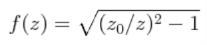

By scaling the graphs for better visualization, we get: 

Setting the effective mass 1.2855709083035553e-29.
At a depth (V) of 1 eV, z0 takes the value 5.773502691896257.
-------------
Even roots: [1.337084671947112, 3.957221234583547].
Odd roots: [2.6623261763770967, 5.1726618674310085].
-------------
We have 4 possible energy levels.


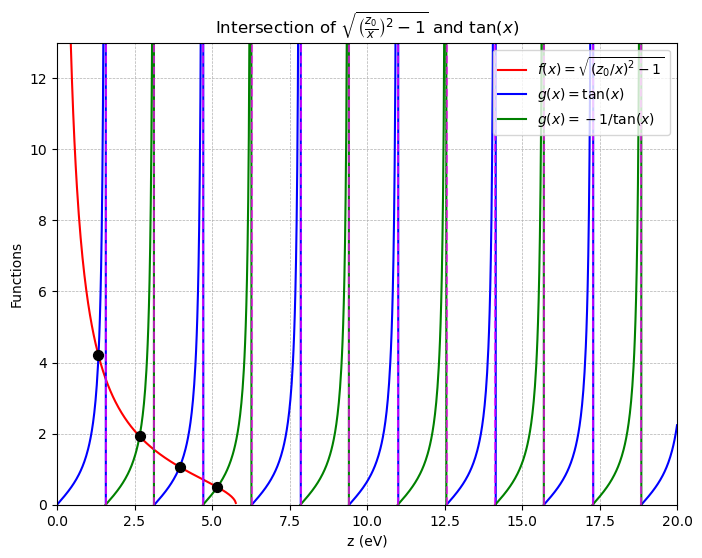

At a depth (V) of 5 eV, z0 takes the value 12.909944487358056.
-------------
Even roots: [1.457646246598085, 4.367290976799287, 7.257026464509038, 10.097470636752218, 12.732405317097065].
Odd roots: [2.913919597334255, 5.815865584713328, 8.68669805781525, 11.472041944844719].
-------------
We have 9 possible energy levels.


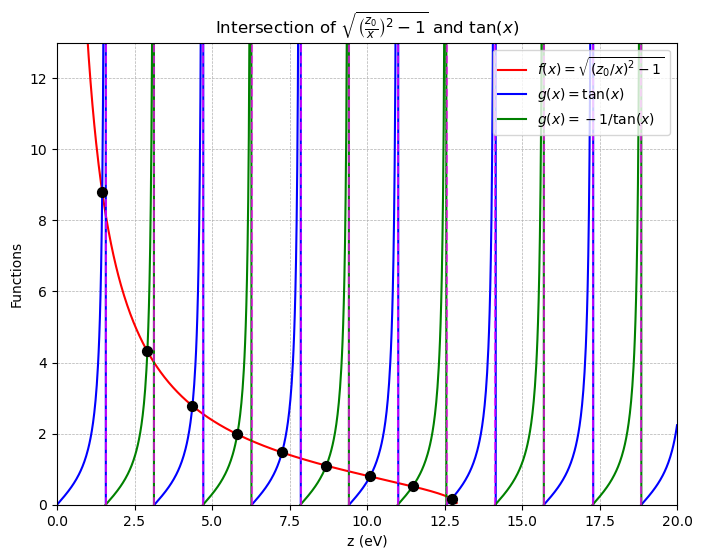

At a depth (V) of 10 eV, z0 takes the value 18.257418583505537.
-------------
Even roots: [1.489141956599489, 4.46530765238972, 7.434585476205783, 10.390171720102503, 13.319517758958655, 16.18862818244796].
Odd roots: [2.9777620118897827, 5.951159931887149, 8.914664480961433, 11.859359910218059, 14.765918074606729, 17.55670764890684].
-------------
We have 12 possible energy levels.


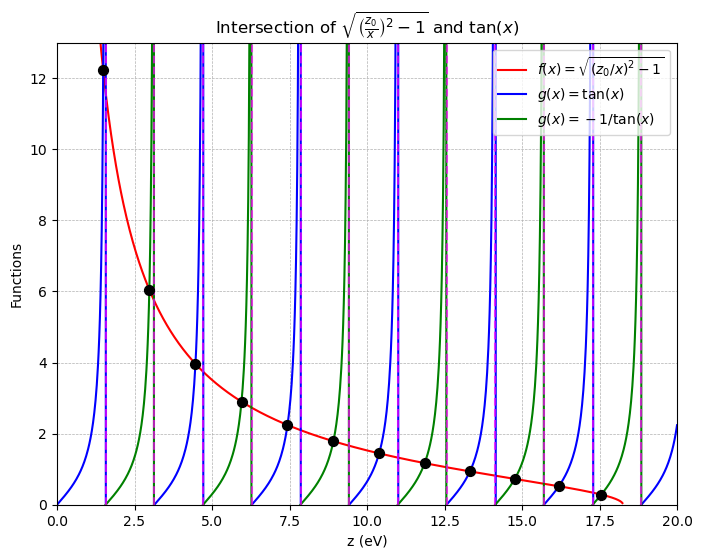

In [44]:
def plot_functions(z0, x_par, x_im):
    x_values = np.linspace(0.001, 20, 1000)
    y_sq = [sq(x, z0) for x in x_values]
    y_ctg = [ctg_func(x) for x in x_values]
    y_tan = [tan_func(x) for x in x_values]

    plt.figure(figsize=(8, 6))
    plt.plot(x_values, y_sq, 'r', label=r'$f(x) = \sqrt{(z_0/x)^2 - 1}$')
    plt.plot(x_values, y_tan, 'b', label=r'$g(x) = \tan(x)$')
    plt.plot(x_values, y_ctg, 'g', label=r'$g(x) = -1/\tan(x)$')

    # Graficar singularidades (asíntotas)
    sing = np.arange(np.pi/2, 20, np.pi/2)
    for s in sing:
        plt.axvline(s, color="magenta", linestyle="--", alpha=0.7)

    # Graficar puntos de intersección pares
    for x in x_par:
        plt.scatter(x, sq(x, z0), color='black', s=50, zorder=5)
    
    # Graficar puntos de intersección impares
    for x in x_im:

        plt.scatter(x, sq(x, z0), color='black', s=50, zorder=5)

    plt.ylim(0, 13)
    plt.xlim(0, 20)
    plt.xlabel("z (eV)")
    plt.ylabel("Functions")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.title(r"Intersection of $\sqrt{\left(\frac{z_0}{x}\right)^2 - 1}$ and $\tan(x)$")
    plt.show()

print(f"Setting the effective mass {m_effe}.")

V_list = [1, 5, 10] 

for i in range(len(V_list)):
    V_list_print = V_list[i]
    V_list[i] = V_list[i] * 1.602 * 10**(-19)

    if __name__ == "__main__":
        
        z0 = (a/Hbar)*np.sqrt(2 * m_effe * V_list[i] )  #Calculamos z0
        
        eps = 1e-5

        x_par = roots_par(z0, eps)
        x_im = roots_im(z0, eps)
        niv_ene = len(x_par) + len(x_im)

        print(f"At a depth (V) of {V_list_print} eV, z0 takes the value {z0}.") 
        print("-------------")
        print(f"Even roots: {x_par}.")
        print(f"Odd roots: {x_im}.")
        print("-------------")
        print(f"We have {niv_ene} possible energy levels.")


        plot_functions(z0, x_par, x_im)     
